In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

import torch.optim as optim

import random


SEED = 1

# 1. Python random
random.seed(SEED)

# 2. NumPy
np.random.seed(SEED)

# 3. PyTorch (CPU)
torch.manual_seed(SEED)

# 4. PyTorch (GPU, if used)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 5. Deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 6. (Optional but strict) enforce determinism
torch.use_deterministic_algorithms(True)

# 7. Environment variable (important for CUDA reproducibility)


# Dataset generator

In [2]:

# ============================================================
# 1. Nonlinear dataset (GROUND TRUTH )
# ============================================================
class NonlinearDataset(Dataset):
    def __init__(self, n_samples=1000, input_dim=1, noise_std=0.25, width=4):
        self.input_dim = input_dim
        self.x = torch.rand(n_samples, input_dim) * 2*width - width  # [-width, width]

        # ground-truth random parameters
        self.W = torch.randn(input_dim, input_dim)
        self.b = torch.randn(1)

        self.y_true = self._true_function(self.x)
        self.y = self.y_true + noise_std * torch.randn_like(self.y_true)

    def _true_function(self, x):
        hidden = torch.tanh(x * (x @ self.W))+torch.exp(-(x-2)**2)
        return hidden.sum(dim=1, keepdim=True) + self.b

    def ground_truth(self, x):
        return self._true_function(x)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# Neural network architecture definition

In [3]:

class NNRegressor(nn.Module):
    def __init__(self,
                 input_dim,
                 hidden_dim=4, ## number of hidden nodes per layer
                 depth=1):  ## number of hidden layers: if depth=0, the model is linear
        super().__init__()
        layers = []
        dim = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(dim, hidden_dim))
            layers.append(nn.Tanh())
            dim = hidden_dim
        if depth>0:
          layers.append(nn.Linear(hidden_dim, 1))
        else:
          layers.append(nn.Linear(input_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Configuration of the regression task

In [4]:
# ============================================================
# 3. Configuration
# ============================================================
input_dim = 2                      # input dimension

dataset = NonlinearDataset(input_dim=input_dim,noise_std=0.1)
train_set, val_set = random_split(dataset, [800, 200])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128)





## Configuration of the learning procedure

In [5]:
epochs = 1500
Steps=[1, 10, 80, 160, 320, 640, 1250, 1500]
lr = 1e-3
model = NNRegressor(input_dim=input_dim,
                                  hidden_dim=10,
                                  depth=2)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

## Training

In [6]:


# ============================================================
# 4. Training with weight + snapshot tracking
# ============================================================
weight_history = []
snapshots = {}

for epoch in range(epochs):
    model.train()
    for x, y in train_loader:
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

        flat_params = torch.cat([p.detach().flatten() for p in model.parameters()])
        weight_history.append(flat_params)

        step = len(weight_history)
        if step in Steps:
            snapshots[step] = [p.detach().clone() for p in model.parameters()]

    model.eval()
    with torch.no_grad():
        val_loss = sum(
            loss_fn(model(x), y).item() for x, y in val_loader
        ) / len(val_loader)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:02d} | train loss = {loss.item():.4f} val loss = {val_loss:.4f}")

weight_history = torch.stack(weight_history)






Epoch 00 | train loss = 0.4901 val loss = 0.4392
Epoch 100 | train loss = 0.0529 val loss = 0.0580
Epoch 200 | train loss = 0.0223 val loss = 0.0267
Epoch 300 | train loss = 0.0263 val loss = 0.0246
Epoch 400 | train loss = 0.0239 val loss = 0.0216
Epoch 500 | train loss = 0.0295 val loss = 0.0213
Epoch 600 | train loss = 0.0261 val loss = 0.0191
Epoch 700 | train loss = 0.0175 val loss = 0.0186
Epoch 800 | train loss = 0.0141 val loss = 0.0174
Epoch 900 | train loss = 0.0122 val loss = 0.0155
Epoch 1000 | train loss = 0.0134 val loss = 0.0150
Epoch 1100 | train loss = 0.0188 val loss = 0.0148
Epoch 1200 | train loss = 0.0094 val loss = 0.0145
Epoch 1300 | train loss = 0.0183 val loss = 0.0142
Epoch 1400 | train loss = 0.0179 val loss = 0.0143


# Visualization

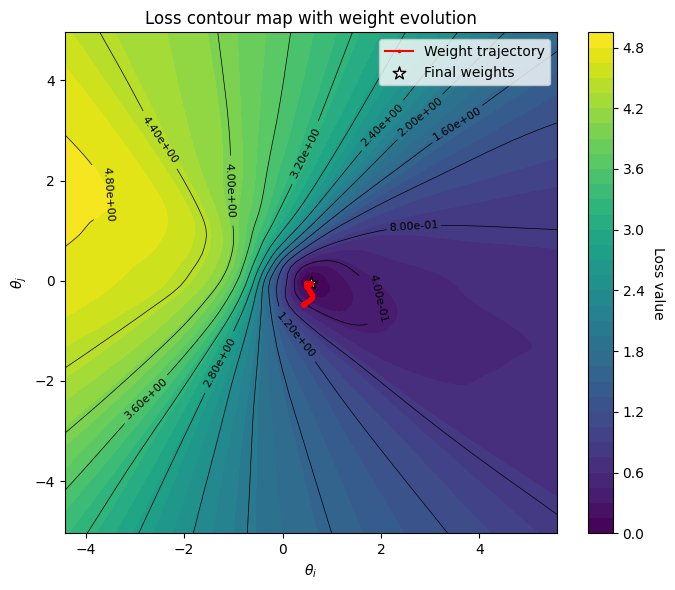

In [7]:

# ============================================================
# 5. Utilities for loss contour visualization
# ============================================================
def set_flat_params(model, flat_params):
    idx = 0
    with torch.no_grad():
        for p in model.parameters():
            n = p.numel()
            p.copy_(flat_params[idx:idx+n].view_as(p))
            idx += n

def empirical_loss(flat_params):
    set_flat_params(model, flat_params)
    with torch.no_grad():
        return loss_fn(model(dataset.x), dataset.y).item()


# ============================================================
# 6. Loss contour (2-parameter slice)
# ============================================================
i, j = 0, 1                    # parameter indices
center = weight_history[-1]
delta = 5
grid = 80

theta_i = torch.linspace(center[i]-delta, center[i]+delta, grid)
theta_j = torch.linspace(center[j]-delta, center[j]+delta, grid)

L = torch.zeros(grid, grid)
for a in range(grid):
    for b in range(grid):
        w = center.clone()
        w[i] = theta_i[a]
        w[j] = theta_j[b]
        L[a, b] = empirical_loss(w)

traj_i = weight_history[:, i].numpy()
traj_j = weight_history[:, j].numpy()
ThetaI, ThetaJ = torch.meshgrid(theta_i, theta_j, indexing="ij")

plt.figure(figsize=(7, 6))

# Filled contours (loss magnitude)
contours = plt.contourf(
    ThetaI, ThetaJ, L,
    levels=40,
    cmap="viridis"
)

# Line contours (same levels)
line_contours = plt.contour(
    ThetaI, ThetaJ, L,
    levels=15,
    colors="black",
    linewidths=0.5
)

# Add numeric labels on some contours
plt.clabel(
    line_contours,
    inline=True,
    fontsize=8,
    fmt="%.2e"   # scientific notation for clarity
)

# Weight trajectory
plt.plot(
    traj_i, traj_j,
    "r.-",
    markersize=3,
    label="Weight trajectory"
)

# Final point
plt.scatter(
    traj_i[-1], traj_j[-1],
    c="white", edgecolor="black",
    s=90, marker="*",
    label="Final weights"
)

# Colorbar showing loss values
cbar = plt.colorbar(contours)
cbar.set_label("Loss value", rotation=270, labelpad=15)

plt.xlabel(r"$\theta_i$")
plt.ylabel(r"$\theta_j$")
plt.title("Loss contour map with weight evolution")
plt.legend()
plt.tight_layout()
plt.show()






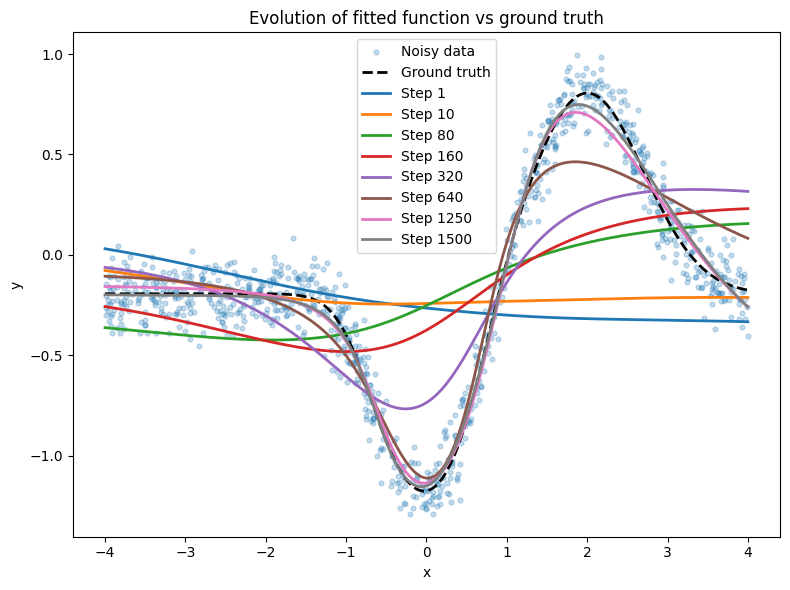

In [ ]:
# ============================================================
# 7. Function evolution vs ground truth
# ============================================================
def evaluate_with_weights(model, x, weights):
    with torch.no_grad():
        old = [p.data.clone() for p in model.parameters()]
        for p, w in zip(model.parameters(), weights):
            p.data.copy_(w)
        y = model(x)
        for p, o in zip(model.parameters(), old):
            p.data.copy_(o)
    return y

if input_dim==1:
  x_plot = torch.linspace(-4, 4, 400).unsqueeze(1)

  y_true = dataset.ground_truth(x_plot)

  plt.figure(figsize=(8,6))

  plt.scatter(dataset.x, dataset.y, s=12, alpha=0.25, label="Noisy data")
  plt.plot(x_plot, y_true, "k--", linewidth=2, label="Ground truth")

  for step, weights in snapshots.items():
      y_hat = evaluate_with_weights(model, x_plot, weights)
      plt.plot(x_plot, y_hat, linewidth=2, label=f"Step {step}")

  plt.xlabel("x")
  plt.ylabel("y")
  plt.title("Evolution of fitted function vs ground truth")
  plt.legend()
  plt.tight_layout()
  plt.show()
